imports ,data cleaning and loading dataset

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv(
    "../data/insurance-data.csv",
    sep="|"
)
df.columns = df.columns.str.strip()

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


creating Important Metrics margin,Loss Ratio and clain fequency

In [3]:
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]
df["HasClaim"] = np.where(
    df["TotalClaims"] > 0,
    1,
    0
)
df["LossRatio"] = (
    df["TotalClaims"] / df["TotalPremium"]
)

create gropups

In [4]:
group_a = df[
    df["Province"] == "Gauteng"
]["TotalClaims"]

group_b = df[
    df["Province"] == "Western Cape"
]["TotalClaims"]

run t test

In [5]:
t_stat, p_value = ttest_ind(
    group_a,
    group_b,
    nan_policy="omit"
)

print("P-value:", p_value)
province_p = p_value

P-value: 0.05632044649871941


decision

In [6]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


Find Zip Codes

In [7]:
df["PostalCode"].value_counts().head()
zip_a = 2000
zip_b = 8000

create groups

In [8]:
group_a = df[
    df["PostalCode"] == zip_a
]["TotalClaims"]

group_b = df[
    df["PostalCode"] == zip_b
]["TotalClaims"]

t-test

In [9]:
t_stat, p_value = ttest_ind(
    group_a,
    group_b,
    nan_policy="omit"
)

print("P-value:", p_value)
zip_p = p_value

P-value: 0.0006252010270582995


Margin Difference Hypothesis

In [10]:
group_a = df[
    df["PostalCode"] == zip_a
]["Margin"]

group_b = df[
    df["PostalCode"] == zip_b
]["Margin"]

t_stat, p_value = ttest_ind(
    group_a,
    group_b,
    nan_policy="omit"
)

print("P-value:", p_value)
margin_p = p_value

P-value: 0.7123247716247572


gender risk hypothesis

In [11]:
male_claims = df[
    df["Gender"] == "Male"
]["TotalClaims"]

female_claims = df[
    df["Gender"] == "Female"
]["TotalClaims"]

t-test

In [12]:
t_stat, p_value = ttest_ind(
    male_claims,
    female_claims,
    nan_policy="omit"
)

print("P-value:", p_value)
gender_p = p_value

P-value: 0.8041073961270342


result table

In [13]:
results = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Zip Code Risk Difference",
        "Margin Difference by Zip Code",
        "Gender Risk Difference"
    ],

    "Test Used": [
        "T-Test",
        "T-Test",
        "T-Test",
        "T-Test"
    ],

    "P-Value": [
        province_p,
        zip_p,
        margin_p,
        gender_p
    ]
})

results["Decision"] = np.where(
    results["P-Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

results

,Hypothesis,Test Used,P-Value,Decision
0,Province Risk Difference,T-Test,0.056320,Fail to Reject H0
1,Zip Code Risk Difference,T-Test,0.000625,Reject H0
2,Margin Difference by Zip Code,T-Test,0.712325,Fail to Reject H0
3,Gender Risk Difference,T-Test,0.804107,Fail to Reject H0


visualization province claims

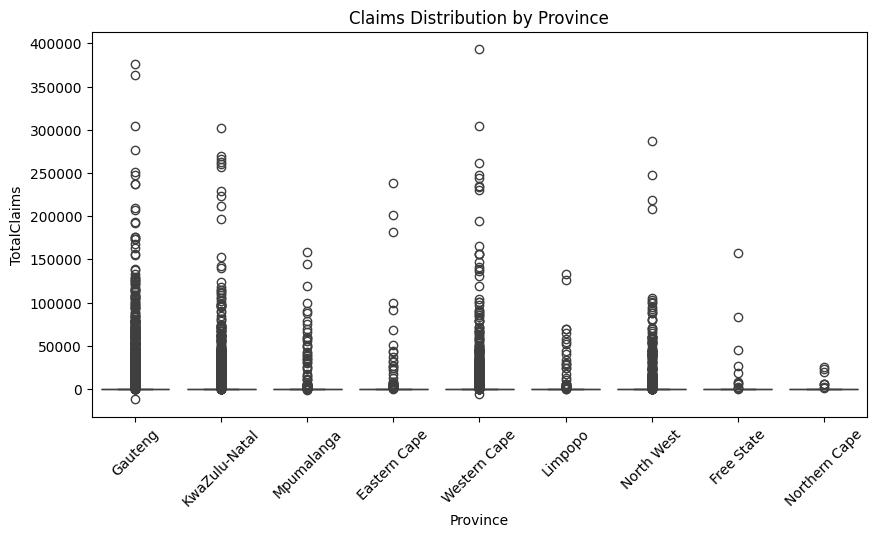

In [14]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x="Province",
    y="TotalClaims",
    data=df
)

plt.xticks(rotation=45)

plt.title("Claims Distribution by Province")

plt.show()

### Interpretation

The hypothesis test compares claim severity between Gauteng and Western Cape.

If the p-value is below 0.05, we reject the null hypothesis and conclude that province influences insurance risk levels.

This suggests that regional pricing adjustments may improve pricing accuracy.